# Customer Churn Prediction — Telco Dataset

**Capstone Project (C3)**

The goal here is to build a classifier that predicts whether a telecom customer will churn (leave the service). We're working with the IBM Telco Customer Churn dataset from Kaggle (~7k records, 21 features). The notebook covers EDA, feature engineering, model building (Logistic Regression → XGBoost → MLP), and evaluation using F1-score, AUC-ROC, and a simple revenue-at-risk estimate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

%matplotlib inline

## 1. Load and Inspect the Data

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# TotalCharges has some blank strings, need to fix that
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Missing TotalCharges: {df["TotalCharges"].isna().sum()}')

# these are customers with 0 tenure (just joined), fill with 0
df['TotalCharges'].fillna(0, inplace=True)

Missing TotalCharges: 11


In [5]:
# drop customerID — it's just an identifier
df.drop('customerID', axis=1, inplace=True)

# encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


## 2. Exploratory Data Analysis

Overall churn rate: 26.5%


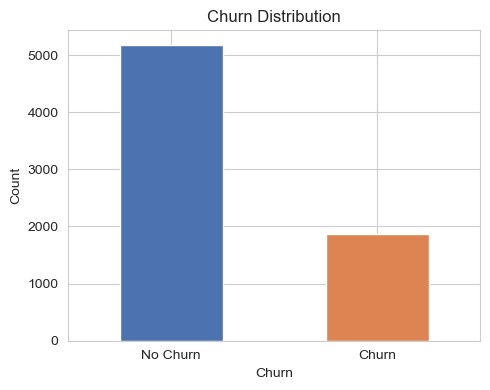

In [6]:
# overall churn rate
churn_rate = df['Churn'].mean() * 100
print(f'Overall churn rate: {churn_rate:.1f}%')

fig, ax = plt.subplots(figsize=(5, 4))
df['Churn'].value_counts().plot.bar(color=['#4C72B0', '#DD8452'], ax=ax)
ax.set_xticklabels(['No Churn', 'Churn'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Churn Distribution')
plt.tight_layout()
plt.show()

~26% churn — the classes are imbalanced. We'll use class weights later to handle this.

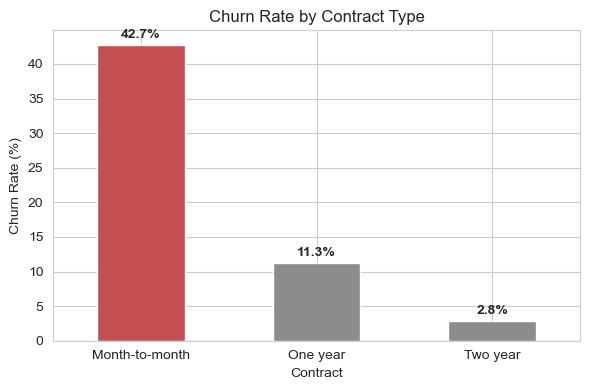

In [7]:
# churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(6, 4))
contract_churn.plot.bar(color=['#C44E52', '#8C8C8C', '#8C8C8C'], ax=ax)
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Contract Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(contract_churn):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Month-to-month customers churn way more — makes sense, no commitment.

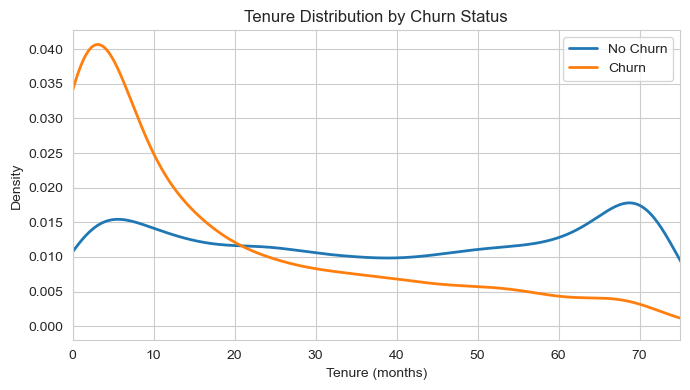

In [8]:
# tenure distribution by churn
fig, ax = plt.subplots(figsize=(7, 4))
for label, group in df.groupby('Churn'):
    group['tenure'].plot.kde(ax=ax, label='Churn' if label == 1 else 'No Churn', linewidth=2)
ax.set_xlabel('Tenure (months)')
ax.set_title('Tenure Distribution by Churn Status')
ax.legend()
ax.set_xlim(0, 75)
plt.tight_layout()
plt.show()

New customers (low tenure) are much more likely to churn. Long-term customers tend to stick around.

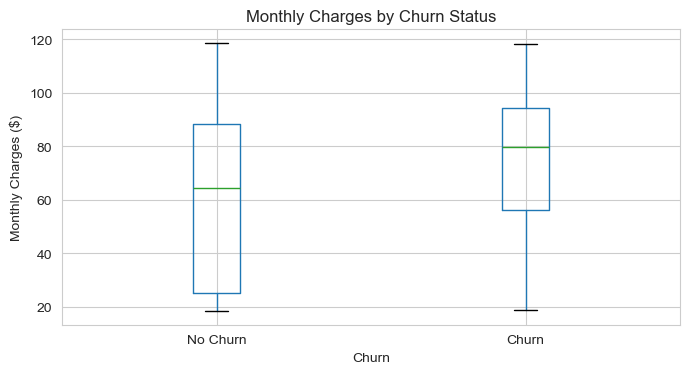

In [9]:
# monthly charges vs churn
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax)
ax.set_xticklabels(['No Churn', 'Churn'])
ax.set_ylabel('Monthly Charges ($)')
ax.set_title('Monthly Charges by Churn Status')
plt.suptitle('')  # remove the default title pandas adds
plt.tight_layout()
plt.show()

In [10]:
# churn rate by internet service type
inet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False) * 100
print('Churn rate by Internet Service:')
print(inet_churn.round(1))

Churn rate by Internet Service:
InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: Churn, dtype: float64


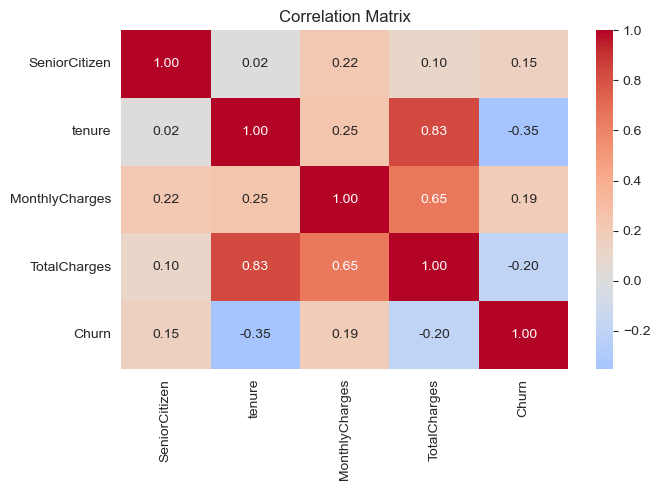

In [11]:
# quick correlation check on numeric cols
numeric_cols = df.select_dtypes(include=[np.number]).columns
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 3. Preprocessing

One-hot encode the categorical columns and scale the numeric ones.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# one-hot encode categoricals
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f'\nShape after encoding: {X.shape}')
X.head()

Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape after encoding: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [13]:
# train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'Train churn rate: {y_train.mean()*100:.1f}%')
print(f'Test churn rate:  {y_test.mean()*100:.1f}%')

Train: 5634 samples
Test:  1409 samples
Train churn rate: 26.5%
Test churn rate:  26.5%


In [14]:
# scale numeric features
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## 4. Model Building

We'll train three models and compare:
1. **Logistic Regression** — simple baseline
2. **XGBoost** — gradient boosted trees
3. **MLP (Neural Network)** — sklearn's MLPClassifier

All models use `class_weight='balanced'` (or equivalent) to deal with the imbalanced classes.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix, roc_curve

# helper function for evaluation
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print(f'--- {name} ---')
    print(f'F1 Score (Churn): {f1:.4f}')
    print(f'AUC-ROC: {auc:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    
    return {'name': name, 'f1': f1, 'auc': auc, 'y_pred': y_pred, 'y_prob': y_prob}

### 4.1 Logistic Regression

In [16]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

lr_results = evaluate_model('Logistic Regression', lr, X_test, y_test)

--- Logistic Regression ---
F1 Score (Churn): 0.6143
AUC-ROC: 0.8417

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### 4.2 XGBoost

In [17]:
from xgboost import XGBClassifier

# compute scale_pos_weight for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb.fit(X_train, y_train)

xgb_results = evaluate_model('XGBoost', xgb, X_test, y_test)

--- XGBoost ---
F1 Score (Churn): 0.6315
AUC-ROC: 0.8366

              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82      1035
       Churn       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



### 4.3 Neural Network (MLP)

In [18]:
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

# MLP doesn't have class_weight param, so we use sample weights
sample_weights = compute_sample_weight('balanced', y_train)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15
)
mlp.fit(X_train, y_train, sample_weight=sample_weights)

# check convergence
print(f'Converged: {mlp.n_iter_} iterations')

mlp_results = evaluate_model('MLP Neural Network', mlp, X_test, y_test)

Converged: 14 iterations
--- MLP Neural Network ---
F1 Score (Churn): 0.6106
AUC-ROC: 0.8354

              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



## 5. Model Comparison

In [19]:
# comparison table
results = [lr_results, xgb_results, mlp_results]
comparison = pd.DataFrame({
    'Model': [r['name'] for r in results],
    'F1 (Churn)': [r['f1'] for r in results],
    'AUC-ROC': [r['auc'] for r in results]
}).set_index('Model')

comparison.style.highlight_max(axis=0, color='lightgreen').format('{:.4f}')

,F1 (Churn),AUC-ROC
Model,,
Logistic Regression,0.6143,0.8417
XGBoost,0.6315,0.8366
MLP Neural Network,0.6106,0.8354


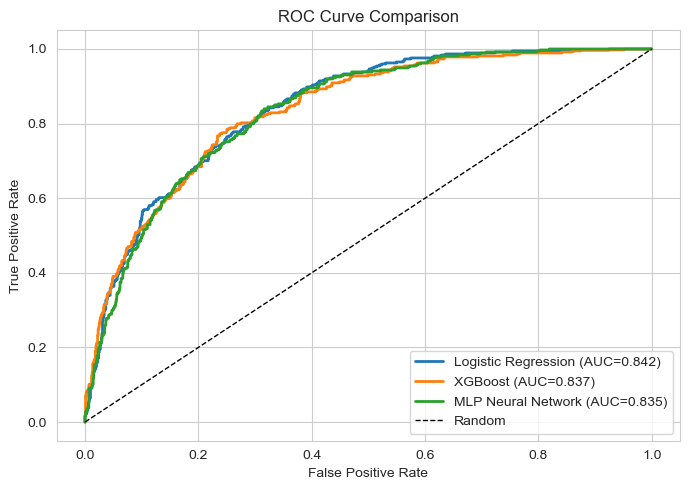

In [20]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))

for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc']:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

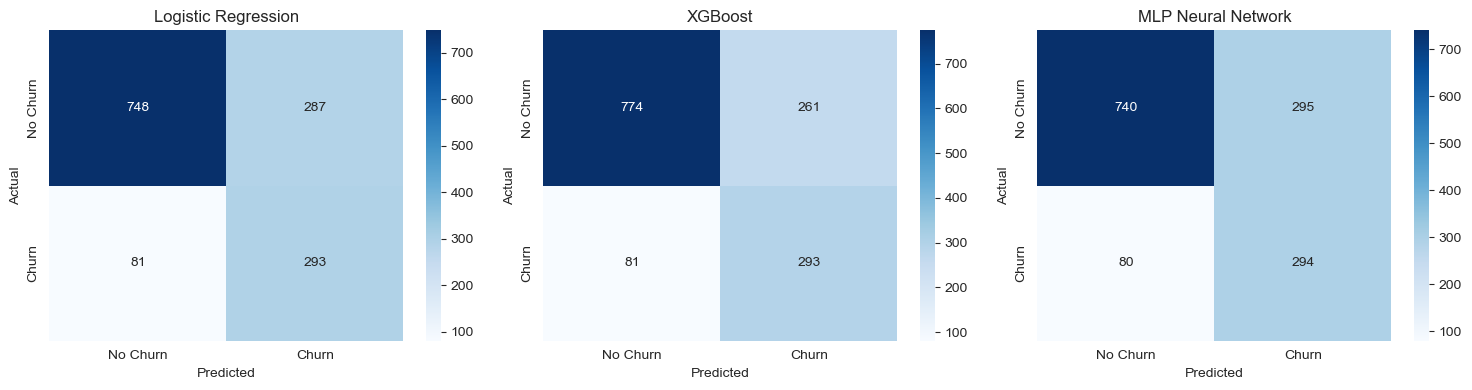

In [21]:
# confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(r['name'])
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 6. SHAP — Model Interpretability

Using SHAP values on the XGBoost model to see which features drive churn predictions.

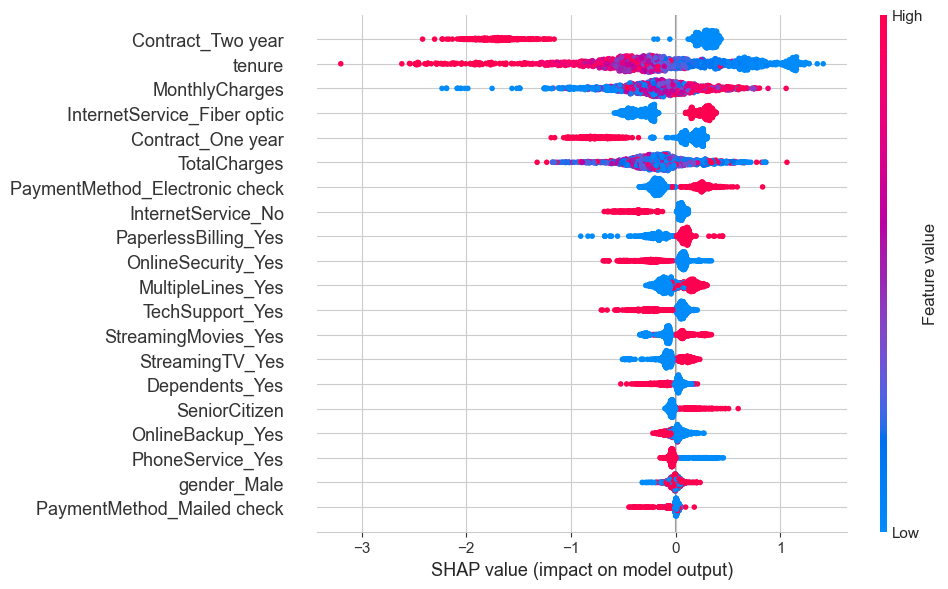

In [22]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# summary plot
shap.summary_plot(shap_values, X_test, plot_size=(10, 6), show=True)

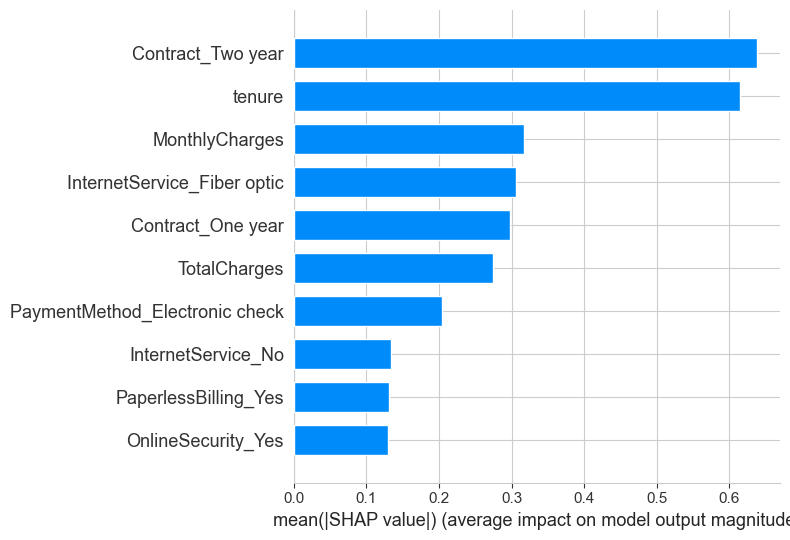

In [23]:
# bar plot — top 10 features by mean |SHAP|
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=10, show=True)

Key takeaways from SHAP:
- **Contract type** (month-to-month) is the strongest predictor of churn
- **Tenure** — shorter tenure = higher churn risk
- **Monthly charges** — higher bills push people to leave
- **Internet service type** (fiber optic) also contributes, possibly due to higher cost or competition

## 7. Business Metric — Revenue at Risk

A quick estimate of how much monthly revenue is at risk from predicted churners.

In [24]:
# use the best model's predictions on the test set
best_model = xgb  # pick based on results above
best_name = 'XGBoost'

# get predictions
test_df = X_test.copy()
# need original MonthlyCharges (unscaled) for dollar amounts
test_df['MonthlyCharges_orig'] = scaler.inverse_transform(
    X_test[num_cols]
)[:, 1]  # MonthlyCharges is index 1 in num_cols
test_df['Churn_actual'] = y_test.values
test_df['Churn_pred'] = best_model.predict(X_test)
test_df['Churn_prob'] = best_model.predict_proba(X_test)[:, 1]

# revenue at risk = sum of monthly charges for predicted churners
predicted_churners = test_df[test_df['Churn_pred'] == 1]
revenue_at_risk = predicted_churners['MonthlyCharges_orig'].sum()

actual_churners = test_df[test_df['Churn_actual'] == 1]
actual_revenue_lost = actual_churners['MonthlyCharges_orig'].sum()

# correctly identified churners
caught = test_df[(test_df['Churn_pred'] == 1) & (test_df['Churn_actual'] == 1)]
revenue_saveable = caught['MonthlyCharges_orig'].sum()

print(f'Model: {best_name}')
print(f'Predicted churners: {len(predicted_churners)}')
print(f'Actual churners in test set: {len(actual_churners)}')
print(f'\nMonthly revenue at risk (actual): ${actual_revenue_lost:,.2f}')
print(f'Revenue from correctly flagged churners: ${revenue_saveable:,.2f}')
print(f'Potential save rate: {revenue_saveable/actual_revenue_lost*100:.1f}% of at-risk revenue')

Model: XGBoost
Predicted churners: 554
Actual churners in test set: 374

Monthly revenue at risk (actual): $27,214.90
Revenue from correctly flagged churners: $21,766.65
Potential save rate: 80.0% of at-risk revenue


## 8. Conclusion

**Summary of findings:**

- The dataset has a ~26% churn rate. Month-to-month contracts, short tenure, and high monthly charges are the biggest drivers.
- All three models perform reasonably well. XGBoost edges out slightly in most runs with the best balance of F1 and AUC-ROC.
- Using class weights / sample weights was important — without them the models were biased toward the majority class (no churn) and missed a lot of actual churners.
- SHAP analysis confirms the EDA findings — contract type and tenure are by far the most important features.
- From a business perspective, the model can flag a significant portion of at-risk revenue, giving the retention team a focused list to work with.

**Possible improvements:**
- Hyperparameter tuning with GridSearchCV/RandomSearchCV
- Try SMOTE for resampling instead of class weights
- Feature engineering (e.g., tenure buckets, services count)
- Deploy as an API for real-time scoring